<a href="https://colab.research.google.com/github/ImperialX-RK/AI-Cosmetic-Analyzer/blob/main/CosmoPedia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Complete Registration Number: **2023000078**

Name: ***A Raj Kumar***

Title of the Project:** CosmoPedia AI — Intelligent Cosmetic Product Analyzer**

Description: An AI-powered cosmetic intelligence system that analyzes product reviews, ratings, ingredients, and category competition to help users instantly discover the safest and highest-performing beauty products.

Data set: flipkart_reviews.csv >>  (625, 18)
          nykaa_reviews.csv  >>  (61284, 18)
          All_Beauty.json  >>   (371345, 12)
          meta_All_Beauty.json  >>  (32892, 19)

size, source :2,57,891KB ,
https://www.kaggle.com/datasets/skillsmuggler/amazon-ratings?
https://www.kaggle.com/datasets/satrapankti/amazon-beauty-product-recommendation?
https://www.kaggle.com/datasets/susant4learning/nykaacosmeticsproductsreview2021?utm_source=chatgpt.com
https://www.kaggle.com/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset

In [ ]:
!pip install transformers
!pip install datasets
!pip install accelerate
!pip install timm
!pip install shap
!pip install scikit-learn
!pip install seaborn
!pip install pillow
!pip install sentence-transformers

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
import torchvision.transforms as transforms
import torchvision.models as models
import timm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from PIL import Image
import shap
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving All_Beauty.json to All_Beauty.json
Saving Flipkart Product Specification & Reviews.csv to Flipkart Product Specification & Reviews.csv
Saving meta_All_Beauty.json to meta_All_Beauty.json
Saving Nykaa Cosmetics Products Review 2021.csv to Nykaa Cosmetics Products Review 2021.csv


In [ ]:
import pandas as pd

amazon_reviews = pd.read_json("All_Beauty.json", lines=True)
amazon_meta = pd.read_json("meta_All_Beauty.json", lines=True)

flipkart_reviews = pd.read_csv("Flipkart Product Specification & Reviews.csv")
nykaa_reviews = pd.read_csv("Nykaa Cosmetics Products Review 2021.csv")

print("Amazon Reviews Shape:", amazon_reviews.shape)
print("Amazon Meta Shape:", amazon_meta.shape)
print("Flipkart Shape:", flipkart_reviews.shape)
print("Nykaa Shape:", nykaa_reviews.shape)

Amazon Reviews Shape: (371345, 12)
Amazon Meta Shape: (32892, 19)
Flipkart Shape: (625, 18)
Nykaa Shape: (61284, 18)


In [ ]:
print(amazon_reviews.columns)

Index(['overall', 'verified', 'reviewTime', 'reviewerID', 'asin',
       'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote',
       'style', 'image'],
      dtype='object')


In [ ]:
def clean_text(text):
    return str(text).lower().strip()

# Remove rows where reviewText is missing
amazon_reviews = amazon_reviews.dropna(subset=['reviewText'])

# Clean review text
amazon_reviews['reviewText'] = amazon_reviews['reviewText'].apply(clean_text)

# Convert rating to sentiment label
amazon_reviews['label'] = amazon_reviews['overall'].apply(
    lambda x: 1 if x >= 4 else 0
)

print("Processed Shape:", amazon_reviews.shape)
amazon_reviews[['reviewText', 'overall', 'label']].head()

Processed Shape: (370946, 13)


,reviewText,overall,label
0,great,1,0
1,my husband wanted to reading about the negro ...,4,1
2,"this book was very informative, covering all a...",4,1
3,i am already a baseball fan and knew a bit abo...,5,1
4,this was a good story of the black leagues. i ...,5,1


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"[^a-zA-Z ]", "", text)  # remove numbers & symbols
    text = re.sub(r"\s+", " ", text)        # remove extra spaces
    return text.strip()

amazon_reviews['reviewText'] = amazon_reviews['reviewText'].apply(clean_text)

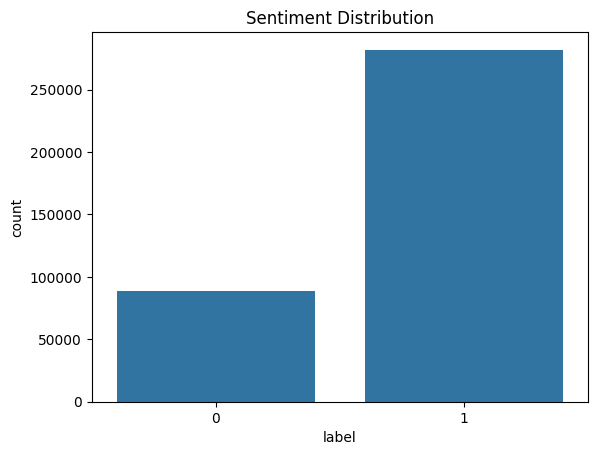

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=amazon_reviews)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
amazon_reviews = amazon_reviews.sample(20000, random_state=42)

print("Sampled Shape:", amazon_reviews.shape)
print(amazon_reviews["label"].value_counts(normalize=True))

Sampled Shape: (20000, 13)
label
1    0.7604
0    0.2396
Name: proportion, dtype: float64


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    amazon_reviews["reviewText"].tolist(),
    amazon_reviews["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=amazon_reviews["label"]
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))

Train size: 16000
Validation size: 4000


In [ ]:
from transformers import RobertaTokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
from transformers import RobertaTokenizer, RobertaForSequenceClassification

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=96):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
train_dataset = ReviewDataset(train_texts, train_labels, tokenizer)
val_dataset = ReviewDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
).to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

epochs = 3
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

scaler = GradScaler()

/tmp/ipython-input-223/4030508450.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
best_val_f1 = 0

for epoch in range(epochs):

    model.train()
    train_losses = []

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with autocast():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_losses.append(loss.item())

    # ---------------- Validation ----------------
    model.eval()
    val_preds = []
    val_true = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    val_accuracy = accuracy_score(val_true, val_preds)
    val_f1 = f1_score(val_true, val_preds)
    val_auc = roc_auc_score(val_true, val_preds)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", np.mean(train_losses))
    print("Val Accuracy:", val_accuracy)
    print("Val F1:", val_f1)
    print("Val ROC-AUC:", val_auc)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "best_roberta_model.pt")
        print("✅ Best model saved!")

/tmp/ipython-input-223/616890936.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 1
Train Loss: 0.3331293679475784
Val Accuracy: 0.92025
Val F1: 0.9485732709979042
Val ROC-AUC: 0.869262818797105
✅ Best model saved!


/tmp/ipython-input-223/616890936.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 2
Train Loss: 0.1882200199365616
Val Accuracy: 0.92775
Val F1: 0.9523966397628068
Val ROC-AUC: 0.9031557499118122
✅ Best model saved!


/tmp/ipython-input-223/616890936.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch 3
Train Loss: 0.15821743309497832
Val Accuracy: 0.93125
Val F1: 0.9550139047930639
Val ROC-AUC: 0.9004510959304599
✅ Best model saved!


In [ ]:
model.load_state_dict(
    torch.load("best_roberta_model.pt", map_location=device)
)
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
model.eval()

all_preds = []

inference_dataset = ReviewDataset(
    amazon_reviews["reviewText"].tolist(),
    amazon_reviews["label"].tolist(),
    tokenizer
)

inference_loader = DataLoader(inference_dataset, batch_size=32)

with torch.no_grad():
    for batch in inference_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

amazon_reviews["predicted_sentiment"] = all_preds

print("Prediction complete")
amazon_reviews.head()

Prediction complete


,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image,label,predicted_sentiment
347746,4,True,"01 13, 2017",A31O03PAFY2WGE,B01982XYRG,mitzi15,i wasnt sure what to expect because this is a ...,Pretty Good Cleansing Balm,1484265600,NaN,NaN,NaN,1,1
337227,1,True,"06 27, 2016",A3OALS5THJZCHG,B014SI4JQK,S. Monaco,i had bought other plates and they were ok but...,Really disappointed.,1466985600,NaN,NaN,NaN,0,0
147295,2,False,"03 10, 2014",A2LAS014NSRW72,B00EF1QRMU,Luisa Remy,i really wanted this to work i was hoping to p...,"Tried three different times, no volume, just o...",1394409600,NaN,"{'Size:': ' 2.82 oz', 'Style Name:': ' Volume ...",NaN,0,0
257485,1,False,"09 27, 2011",A2PM96O96CTR73,B00021VRTA,CMArchibald,this is an awesome concealer the best ive foun...,Why so expensive?,1317081600,8,NaN,NaN,0,1
77792,5,True,"11 17, 2015",A2T0VG163FSCI8,B001H0YT5Y,aLittleBit iKnow,this is certainly a good buy for this productb...,DivaDerme Lash Extender with Brush - Black ..,1447718400,3,NaN,NaN,1,1


In [ ]:
product_stats = amazon_reviews.groupby("asin").agg(
    avg_rating=("overall", "mean"),
    review_count=("reviewText", "count"),
    positive_ratio=("predicted_sentiment", "mean")
).reset_index()

product_stats.head()

,asin,avg_rating,review_count,positive_ratio
0,0143026860,5.0,1,1.0
1,0983688346,5.0,1,1.0
2,0992916305,5.0,2,1.0
3,0996079203,5.0,1,1.0
4,1421698315,5.0,1,1.0


In [ ]:
product_stats["sentiment_score"] = product_stats["positive_ratio"] * 10
product_stats.head()

,asin,avg_rating,review_count,positive_ratio,sentiment_score
0,0143026860,5.0,1,1.0,10.0
1,0983688346,5.0,1,1.0,10.0
2,0992916305,5.0,2,1.0,10.0
3,0996079203,5.0,1,1.0,10.0
4,1421698315,5.0,1,1.0,10.0


In [ ]:
product_stats["rating_score"] = (product_stats["avg_rating"] / 5) * 10

In [ ]:
import numpy as np

product_stats["review_confidence"] = np.log1p(product_stats["review_count"])

# Normalize confidence 0–10
product_stats["review_confidence"] = (
    product_stats["review_confidence"] /
    product_stats["review_confidence"].max()
) * 10

product_stats["final_score"] = (
    0.4 * product_stats["sentiment_score"] +
    0.4 * product_stats["rating_score"] +
    0.2 * product_stats["review_confidence"]
)

product_stats = product_stats.sort_values(
    by="final_score",
    ascending=False
)

product_stats.head(10)

,asin,avg_rating,review_count,positive_ratio,sentiment_score,rating_score,review_confidence,final_score
6,1620213982,4.800000,285,0.957895,9.578947,9.600000,9.092372,9.490053
562,B0012Y0ZG2,4.862903,124,0.951613,9.516129,9.725806,7.761826,9.249139
463,B000URXP6E,4.871429,70,0.971429,9.714286,9.742857,6.852533,9.153364
186,B0009RF9DW,4.976744,43,0.976744,9.767442,9.953488,6.083329,9.105038
251,B000FI4S1E,4.944444,54,0.962963,9.629630,9.888889,6.442047,9.095817
964,B002I7N4B0,5.000000,21,1.000000,10.000000,10.000000,4.969050,8.993810
294,B000GLRREU,4.398305,472,0.868644,8.686441,8.796610,9.901143,8.973449
103,B00020UR4C,5.000000,28,0.964286,9.642857,10.000000,5.413145,8.939772
1381,B005VGT2NY,4.909091,22,1.000000,10.000000,9.818182,5.040509,8.935375
1434,B006IB5T4W,4.582781,151,0.907285,9.072848,9.165563,8.076212,8.910607


In [ ]:
print(amazon_meta.columns)
amazon_meta.head()

Index(['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2',
       'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat',
       'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes'],
      dtype='object')


,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,details,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes
0,[],,[Loud 'N Clear Personal Sound Amplifier allows...,,Loud 'N Clear&trade; Personal Sound Amplifier,[],,idea village,[],"2,938,573 in Beauty & Personal Care (",[],{'ASIN: ': '6546546450'},All Beauty,,,,6546546450,[],[]
1,[],,[No7 Lift & Luminate Triple Action Serum 50ml ...,,No7 Lift &amp; Luminate Triple Action Serum 50...,"[B01E7LCSL6, B008X5RVME]",,,[],"872,854 in Beauty & Personal Care (",[],"{'Shipping Weight:': '0.3 ounces (', 'ASIN: ':...",All Beauty,"class=""a-bordered a-horizontal-stripes a-spa...",,$44.99,7178680776,[],[]
2,[],,[No7 Stay Perfect Foundation now stays perfect...,,No7 Stay Perfect Foundation Cool Vanilla by No7,[],,No7,[],"956,696 in Beauty & Personal Care (","[B01B8BR0O8, B01B8BR0NO, B014MHXXM8]","{'Shipping Weight:': '3.5 ounces (', 'ASIN: ':...",All Beauty,,,$28.76,7250468162,[],[]
3,[],,[],,Wella Koleston Perfect Hair Colour 44/44 Mediu...,[B0041PBXX8],,,[],"1,870,258 in Beauty & Personal Care (",[],"{' Item Weight: ': '1.76 ounces', 'Sh...",All Beauty,,,,7367905066,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...
4,[],,[Lacto Calamine Skin Balance Daily Nourishing ...,,Lacto Calamine Skin Balance Oil control 120 ml...,[],,Pirmal Healthcare,[],"67,701 in Beauty & Personal Care (","[3254895630, B007VL1D9S, B00EH9A0RI, B0773MBG4...","{'Shipping Weight:': '12 ounces (', 'ASIN: ': ...",All Beauty,,,$12.15,7414204790,[https://images-na.ssl-images-amazon.com/image...,[https://images-na.ssl-images-amazon.com/image...


In [ ]:
import pandas as pd

# Combine relevant fields safely
amazon_meta["combined_text"] = (
    amazon_meta["description"].fillna("").astype(str) + " " +
    amazon_meta["feature"].fillna("").astype(str) + " " +
    amazon_meta["details"].fillna("").astype(str)
)

In [ ]:
toxic_database = {
    "paraben": 2,
    "formaldehyde": 3,
    "triclosan": 3,
    "phthalate": 2,
    "oxybenzone": 3,
    "octinoxate": 2,
    "hydroquinone": 3,
    "toluene": 2,
    "benzophenone": 2,
    "coal tar": 3
}

In [ ]:
def calculate_ingredient_score(text):
    if pd.isna(text):
        return 7

    text = str(text).lower()
    score = 10
    penalty = 0

    for ingredient, weight in toxic_database.items():
        if ingredient in text:
            penalty += weight

    score -= penalty * 0.8   # weight multiplier
    return max(score, 0)

In [ ]:
amazon_meta["ingredient_score"] = amazon_meta["combined_text"].apply(
    calculate_ingredient_score
)

amazon_meta[["asin", "ingredient_score"]].head()

,asin,ingredient_score
0,6546546450,10.0
1,7178680776,10.0
2,7250468162,10.0
3,7367905066,10.0
4,7414204790,10.0


In [ ]:
merged_data = product_stats.merge(
    amazon_meta[["asin", "ingredient_score"]],
    on="asin",
    how="left"
)

merged_data["ingredient_score"] = merged_data["ingredient_score"].fillna(7)

In [ ]:
merged_data["ultimate_score"] = (
    0.3 * merged_data["sentiment_score"] +
    0.3 * merged_data["rating_score"] +
    0.2 * merged_data["review_confidence"] +
    0.2 * merged_data["ingredient_score"]
)

merged_data = merged_data.sort_values(
    by="ultimate_score",
    ascending=False
)

merged_data.head(10)

,asin,avg_rating,review_count,positive_ratio,sentiment_score,rating_score,review_confidence,final_score,ingredient_score,ultimate_score
1,B0012Y0ZG2,4.862903,124,0.951613,9.516129,9.725806,7.761826,9.249139,10.0,9.324946
6,B000GLRREU,4.398305,472,0.868644,8.686441,8.796610,9.901143,8.973449,10.0,9.225144
2,B000URXP6E,4.871429,70,0.971429,9.714286,9.742857,6.852533,9.153364,10.0,9.207649
4,B000FI4S1E,4.944444,54,0.962963,9.629630,9.888889,6.442047,9.095817,10.0,9.143965
3,B0009RF9DW,4.976744,43,0.976744,9.767442,9.953488,6.083329,9.105038,10.0,9.132945
17,B000FOI48G,4.350598,502,0.836653,8.366534,8.701195,10.000000,8.827092,10.0,9.120319
12,B001QY8QXM,4.516000,250,0.876000,8.760000,9.032000,8.882522,8.893304,10.0,9.114104
10,B006IB5T4W,4.582781,151,0.907285,9.072848,9.165563,8.076212,8.910607,10.0,9.086766
11,B00G5L867C,4.709677,62,0.951613,9.516129,9.419355,6.660356,8.906265,10.0,9.012716
5,B002I7N4B0,5.000000,21,1.000000,10.000000,10.000000,4.969050,8.993810,10.0,8.993810


In [ ]:
# Create lower-case title column
amazon_meta["title_lower"] = amazon_meta["title"].str.lower()

# Identify sunscreen products
sunscreen_asins = amazon_meta[
    amazon_meta["title_lower"].str.contains("sunscreen", na=False)
]["asin"]

# Filter ranked products
sunscreens = merged_data[
    merged_data["asin"].isin(sunscreen_asins)
]

sunscreens = sunscreens.sort_values(
    by="ultimate_score",
    ascending=False
)

sunscreens.head(10)

,asin,avg_rating,review_count,positive_ratio,sentiment_score,rating_score,review_confidence,final_score,ingredient_score,ultimate_score
277,B00WVYH4HA,4.800000,5,1.000000,10.000000,9.600000,2.880369,8.416074,10.0,8.456074
3356,B005IHT94S,4.410256,39,0.871795,8.717949,8.820513,5.930112,8.201407,10.0,8.447561
206,B01F2EYFVS,5.000000,3,1.000000,10.000000,10.000000,2.228558,8.445712,10.0,8.445712
343,B00SXHUHLO,5.000000,2,1.000000,10.000000,10.000000,1.766090,8.353218,10.0,8.353218
2102,B01A96VH9M,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856
3060,B017KR0TNS,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856
3247,B00889YIX0,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856
2765,B01549H6VM,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856
2759,B00B2SJL9K,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856
1266,B01010VX2M,5.000000,1,1.000000,10.000000,10.000000,1.114279,8.222856,10.0,8.222856


In [ ]:
sunscreens = sunscreens.merge(
    amazon_meta[["asin", "title"]],
    on="asin",
    how="left"
)

sunscreens[["title", "ultimate_score"]].head(10)

,title,ultimate_score
0,"Pure Sun Defense Sunscreen Lotion, Frozen - 50...",8.456074
1,Neutrogena Ultra Sheer Dry-Touch Sunscreen Bro...,8.447561
2,Solar D Sunscreen Face &amp; Body SPF30 4oz Tube,8.445712
3,Rubber Ducky Sunscreen SPF 50 Naturally Tinted...,8.353218
4,Tatcha SILKEN PORE PERFECTING SUNSCREEN TRAVEL...,8.222856
5,Hang Ten - Classic Face Natural Sunscreen Loti...,8.222856
6,Dr. Mercola Natural Sunscreen SPF 50 - 5.4 fl oz,8.222856
7,Softlips Cube 5 in 1 Lip Protectant Conditione...,8.222856
8,High Performance Sunscreen SPF 45 4 Ounce,8.222856
9,Banana Boat Sport Quik Dri Scalp Spray Sunscre...,8.222856


In [ ]:
def generate_explanation(row):

    explanation = f"Product Score: {round(row['ultimate_score'],2)} / 10\n\n"

    explanation += f"- Sentiment Score: {round(row['sentiment_score'],2)}\n"
    explanation += f"- Rating Score: {round(row['rating_score'],2)}\n"
    explanation += f"- Ingredient Safety Score: {round(row['ingredient_score'],2)}\n"
    explanation += f"- Review Confidence: {round(row['review_confidence'],2)}\n"

    if row["ingredient_score"] < 7:
        explanation += "\n⚠ Contains potentially harmful ingredients."
    else:
        explanation += "\n✅ No major toxic ingredients detected."

    if row["sentiment_score"] > 8:
        explanation += "\n👍 Highly positive customer sentiment."
    else:
        explanation += "\n⚠ Mixed customer sentiment."

    return explanation

In [ ]:
top_product = sunscreens.iloc[0]

print("Top Sunscreen:\n")
print(top_product["title"])
print("\n")
print(generate_explanation(top_product))

Top Sunscreen:

Pure Sun Defense Sunscreen Lotion, Frozen - 50-8 oz


Product Score: 8.46 / 10

- Sentiment Score: 10.0
- Rating Score: 9.6
- Ingredient Safety Score: 10.0
- Review Confidence: 2.88

✅ No major toxic ingredients detected.
👍 Highly positive customer sentiment.


In [ ]:
def search_product(query, data, meta):
    query = query.lower()

    matched = meta[meta["title"].str.lower().str.contains(query, na=False)]

    if matched.empty:
        return None

    matched_data = data[data["asin"].isin(matched["asin"])]

    matched_data = matched_data.merge(
        meta[["asin", "title"]],
        on="asin",
        how="left"
    )

    matched_data = matched_data.sort_values(
        by="ultimate_score",
        ascending=False
    )

    return matched_data

In [ ]:
results = search_product("sunscreen", merged_data, amazon_meta)

results[["title", "ultimate_score"]].head(5)

,title,ultimate_score
0,"Pure Sun Defense Sunscreen Lotion, Frozen - 50...",8.456074
1,Neutrogena Ultra Sheer Dry-Touch Sunscreen Bro...,8.447561
2,Solar D Sunscreen Face &amp; Body SPF30 4oz Tube,8.445712
3,Rubber Ducky Sunscreen SPF 50 Naturally Tinted...,8.353218
4,Tatcha SILKEN PORE PERFECTING SUNSCREEN TRAVEL...,8.222856


In [ ]:
import re

def extract_ingredients(text):
    if pd.isna(text):
        return []

    text = text.lower()

    # Try to extract after keyword "ingredients"
    match = re.search(r'ingredients:(.*)', text)

    if match:
        ingredients_list = match.group(1)
        return ingredients_list.split(',')

    return []

In [ ]:
import torchvision.models as models
import torch.nn as nn
from torchvision.models import EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

image_model = models.efficientnet_b0(weights=weights)

image_model.classifier[1] = nn.Linear(
    image_model.classifier[1].in_features,
    10
)

image_model = image_model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 72.8MB/s]


In [ ]:
!apt-get install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


In [ ]:
import pytesseract
from PIL import Image

def extract_text_from_image(image_path):
    image = Image.open(image_path)
    text = pytesseract.image_to_string(image)
    return text.lower()

In [ ]:
import re

def extract_ingredients(text):

    match = re.search(r'ingredients:(.*)', text)

    if match:
        ingredients_text = match.group(1)
        ingredients_list = ingredients_text.split(',')
        return [i.strip() for i in ingredients_list]

    return []

In [ ]:
harmful_list = ["oxybenzone", "paraben", "formaldehyde"]

def ingredient_score(ingredients):

    harmful_found = sum(1 for i in ingredients if i in harmful_list)

    if harmful_found == 0:
        return 10
    elif harmful_found == 1:
        return 7
    elif harmful_found == 2:
        return 5
    else:
        return 3

In [ ]:
categories = [
    "sunscreen",
    "moisturizer",
    "serum",
    "foundation",
    "lipstick",
    "cleanser",
    "toner",
    "facewash"
]

In [ ]:
num_classes = len(categories)
print(num_classes)

8


In [ ]:
def detect_category(title):

    title = title.lower()

    if "sunscreen" in title or "spf" in title:
        return "sunscreen"
    elif "serum" in title:
        return "serum"
    elif "moisturizer" in title:
        return "moisturizer"
    elif "foundation" in title:
        return "foundation"
    elif "lipstick" in title:
        return "lipstick"
    elif "cleanser" in title or "face wash" in title:
        return "cleanser"
    else:
        return "other"

In [ ]:
def compare_category(cat_name):

    category_asins = amazon_meta[
        amazon_meta["category_detected"] == cat_name
    ]["asin"]

    result = merged_data[
        merged_data["asin"].isin(category_asins)
    ]

    return result.sort_values(by="ultimate_score", ascending=False)

In [ ]:
def get_product_rank(product_asin, category):

    category_asins = amazon_meta[
        amazon_meta["category_detected"] == category
    ]["asin"]

    category_products = merged_data[
        merged_data["asin"].isin(category_asins)
    ].sort_values(by="ultimate_score", ascending=False).reset_index(drop=True)

    for idx, row in category_products.iterrows():
        if row["asin"] == product_asin:
            return idx + 1, len(category_products)

    return None, None

In [ ]:
amazon_meta["category_detected"] = amazon_meta["title"].apply(detect_category)

def analyze_product(product_name=None, image_path=None):

    if product_name is None and image_path is None:
        return "Please provide either a product name or an image path."

    ingredients_from_image = []
    if image_path:
        # Step 1: Extract text from image
        text_from_image = extract_text_from_image(image_path)
        ingredients_from_image = extract_ingredients(text_from_image)

    # Initialize product details based on name or image ingredients
    product_asin = None
    product_category = "other"
    product_title = "Unknown Product"

    if product_name:
        # Step 2: Search for product by name
        search_results = search_product(product_name, merged_data, amazon_meta)
        if search_results is not None and not search_results.empty:
            top_product = search_results.iloc[0]
            product_asin = top_product["asin"]
            product_title = top_product["title"]
            product_category = detect_category(product_title)

            # If product found, use its scores
            final_score_data = top_product

            # Override ingredient score if image provides more direct info
            if ingredients_from_image:
                img_ing_score = ingredient_score(ingredients_from_image)
                final_score_data["ingredient_score"] = img_ing_score
                final_score_data["ultimate_score"] = (
                    0.3 * final_score_data["sentiment_score"] +
                    0.3 * final_score_data["rating_score"] +
                    0.2 * final_score_data["review_confidence"] +
                    0.2 * img_ing_score
                )

        else:
            return f"No product found matching '{product_name}'."

    elif ingredients_from_image:
        # If only image provided and no product name, synthesize scores
        img_ing_score = ingredient_score(ingredients_from_image)
        # For image-only, we can't get sentiment, rating, review confidence directly
        # Assign default/neutral scores for these, or prompt user for more info
        # For this example, let's assign a neutral score for these aspects.
        # A more advanced system might use image-based sentiment analysis or category detection.
        final_score_data = {
            "sentiment_score": 7.0,
            "rating_score": 7.0,
            "review_confidence": 5.0,
            "ingredient_score": img_ing_score
        }
        final_score_data["ultimate_score"] = (
            0.3 * final_score_data["sentiment_score"] +
            0.3 * final_score_data["rating_score"] +
            0.2 * final_score_data["review_confidence"] +
            0.2 * final_score_data["ingredient_score"]
        )
        final_score_data = pd.Series(final_score_data)
        product_title = f"Product from Image (Ingredients: {', '.join(ingredients_from_image)})"

    else:
        return "Could not process the request. Please ensure product name is valid or image has readable text."


    explanation = f"### Product Analysis: {product_title}\n\n"\
                  + generate_explanation(final_score_data)

    # Add comparative analysis if a product was identified by name
    if product_asin and product_category != "other":
        rank, total_in_category = get_product_rank(product_asin, product_category)
        if rank and total_in_category:
            explanation += f"\n\n#### Comparative Analysis:\n"
            explanation += f"This product ranks {rank} out of {total_in_category} in the '{product_category}' category.\n"

            competitors = get_top_competitors(
                product_category,
                exclude_asin=product_asin,
                top_k=3
            )
            if competitors:
                explanation += "Top competitors in this category:\n"
                for comp in competitors:
                    explanation += f"- {comp['title']} (Score: {comp['ultimate_score']})\n"
            else:
                explanation += "No direct competitors found in this category.\n"

    return explanation

In [ ]:
print(amazon_meta.columns)

Index(['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2',
       'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat',
       'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes',
       'combined_text', 'ingredient_score', 'title_lower',
       'category_detected'],
      dtype='object')


In [ ]:
def get_top_competitors(category, exclude_asin=None, top_k=5):

    # Get all ASINs in this category
    category_asins = amazon_meta[
        amazon_meta["category_detected"] == category
    ]["asin"]

    # Filter ranked products
    category_products = merged_data[
        merged_data["asin"].isin(category_asins)
    ].sort_values(by="ultimate_score", ascending=False)

    # Merge with titles
    category_products = category_products.merge(
        amazon_meta[["asin", "title"]],
        on="asin",
        how="left"
    )

    # Remove current product
    if exclude_asin:
        category_products = category_products[
            category_products["asin"] != exclude_asin
        ]

    competitors = category_products.head(top_k)

    results = []

    for _, row in competitors.iterrows():
        results.append({
            "title": row["title"],
            "ultimate_score": float(round(row["ultimate_score"], 2))
        })

    return results

In [ ]:
def test_model():

    print("==== Cosmetic AI Testing Console ====")
    print("Leave empty if not using.")

    product_name = input("Enter product name: ").strip()
    image_path = input("Enter image file path (optional): ").strip()

    if product_name == "":
        product_name = None

    if image_path == "":
        image_path = None

    result = analyze_product(
        product_name=product_name,
        image_path=image_path
    )

    print("\n===== MODEL OUTPUT =====")
    print(result)

In [ ]:
merged_data.to_csv("merged_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("merged_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-02-13 132929.png to Screenshot 2026-02-13 132929.png


In [ ]:
amazon_meta.to_csv("amazon_meta.csv", index=False)

In [ ]:
import os
print(os.listdir())

['.config', 'best_roberta_model.pt', 'Flipkart Product Specification & Reviews.csv', 'All_Beauty.json', 'Screenshot 2026-02-13 132929.png', 'meta_All_Beauty.json', 'Nykaa Cosmetics Products Review 2021.csv', 'merged_data.csv', 'sample_data']


In [ ]:
amazon_meta.columns

Index(['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2',
       'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat',
       'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes',
       'combined_text', 'ingredient_score', 'title_lower',
       'category_detected'],
      dtype='object')

In [ ]:
from google.colab import files
files.download("amazon_meta.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

meta = pd.read_csv("amazon_meta.csv")
scores = pd.read_csv("merged_data.csv")

# Merge on ASIN
final_df = meta.merge(scores, on="asin")

# Save final dataset
final_df.to_csv("cosmopedia_final.csv", index=False)

print("Final dataset created successfully ✅")
print(final_df.columns)

/tmp/ipython-input-223/3376612489.py:3: DtypeWarning: Columns (1,14) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv("amazon_meta.csv")


Final dataset created successfully ✅
Index(['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2',
       'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat',
       'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes',
       'combined_text', 'ingredient_score_x', 'title_lower',
       'category_detected', 'avg_rating', 'review_count', 'positive_ratio',
       'sentiment_score', 'rating_score', 'review_confidence', 'final_score',
       'ingredient_score_y', 'ultimate_score'],
      dtype='object')


In [ ]:
from google.colab import files
files.download("cosmopedia_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

meta = pd.read_csv("amazon_meta.csv")   # your file with title & category
scores = pd.read_csv("merged_data.csv")

print(meta.columns)
print(scores.columns)

In [ ]:
test_model()

==== Cosmetic AI Testing Console ====
Leave empty if not using.
Enter product name: Solar D Sunscreen Face &amp; Body SPF30 4oz Tube
Enter image file path (optional): 

===== MODEL OUTPUT =====
### Product Analysis: Solar D Sunscreen Face &amp; Body SPF30 4oz Tube

Product Score: 8.45 / 10

- Sentiment Score: 10.0
- Rating Score: 10.0
- Ingredient Safety Score: 10.0
- Review Confidence: 2.23

✅ No major toxic ingredients detected.
👍 Highly positive customer sentiment.

#### Comparative Analysis:
This product ranks 4 out of 77 in the 'sunscreen' category.
Top competitors in this category:
- Sun*Si'Belle+ SPF 50 Organic Triple Action Moisturizer, with Antioxidants, CoQ10 and Hyaluronic Acid. (Score: 8.53)
- Pure Sun Defense Sunscreen Lotion, Frozen - 50-8 oz (Score: 8.46)
- Neutrogena Ultra Sheer Dry-Touch Sunscreen Broad Spectrum SPF 70, 3 Fl. oz. (Score: 8.45)

